# Aha Moment Detector
**USC EEG Creativity Study**

Binary classification: given an EEG epoch, does it contain an aha moment or not?

- **Positive examples:** EEG epochs centered on aha moments (-2s to +2s) from aha_events.json
- **Negative examples:** EEG epochs from non-aha windows of equal length
- **Models:** EEGNet, CNN-LSTM
- **Validation:** Leave-One-Subject-Out cross-validation

## 0. Imports

In [1]:
import os
import glob
import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt

import mne
mne.set_log_level('ERROR')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import (accuracy_score, roc_auc_score, f1_score,
                             classification_report, confusion_matrix,
                             ConfusionMatrixDisplay)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('PyTorch:', torch.__version__)
print('Device:', device)
print('All imports successful!')

PyTorch: 2.12.0
Device: cpu
All imports successful!


## 1. Configuration

In [2]:
BASE_PATH   = "/Users/agastyabassi/Library/CloudStorage/OneDrive-SharedLibraries-UniversityofSouthernCalifornia/Athena Saghi - EEG Cleaning/clean"
# aha_events.json is in the repo root — adjust if needed
AHA_JSON    = "../aha_events.json"
OUTPUT_DIR  = "./aha_detector_results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

NON_BRAIN   = ['A1', 'A2', 'REF', 'GND']
EPOCH_TMIN  = -2.0   # seconds before aha moment
EPOCH_TMAX  =  2.0   # seconds after aha moment
BUFFER_SEC  =  4.0   # min gap between negative window and any aha moment

BATCH_SIZE  = 16
EPOCHS      = 50
LR          = 1e-3
DROPOUT     = 0.5

print('Configuration loaded!')

Configuration loaded!


## 2. Load aha_events.json

In [3]:
with open(AHA_JSON, 'r') as f:
    aha_events = json.load(f)

def timestamp_to_seconds(ts):
    """Convert HH:MM:SS.ms string to seconds."""
    parts = ts.split(':')
    h = float(parts[0])
    m = float(parts[1])
    s = float(parts[2])
    return h * 3600 + m * 60 + s

# Count total aha moments
total_aha = 0
for subj, conditions in aha_events.items():
    for cond_block, info in conditions.items():
        total_aha += len(info['times'])

print(f'Participants in JSON: {len(aha_events)}')
print(f'Total aha moments: {total_aha}')
print(f'\nExample entry (P10):')
for cond_block, info in list(aha_events.get('P10', {}).items())[:2]:
    print(f'  {cond_block}: {len(info["times"])} aha moments')

Participants in JSON: 19
Total aha moments: 256

Example entry (P10):
  treatment - A2: 5 aha moments
  treatment - B3: 6 aha moments


## 3. Match aha events to EEG files

JSON keys look like `'treatment - B4'` while filenames look like `P23_treatment_B4_postcleaning1.set`.

In [4]:
def find_eeg_file(subject, cond_block, base_path):
    """
    Match a JSON entry to its EEG file.
    cond_block is like 'treatment - B4' -> we need P23_treatment_B4_*.set
    """
    parts = cond_block.split(' - ')
    condition = parts[0].strip()   # 'treatment' or 'control'
    block     = parts[1].strip()   # 'B4'
    
    pattern = os.path.join(base_path, f'{subject}_{condition}_{block}_*.set')
    matches = glob.glob(pattern)
    return matches[0] if matches else None

# Test matching
found, missing = 0, 0
for subj, conditions in aha_events.items():
    for cond_block in conditions:
        fpath = find_eeg_file(subj, cond_block, BASE_PATH)
        if fpath:
            found += 1
        else:
            missing += 1

print(f'Matched files: {found}')
print(f'Missing files: {missing}')

Matched files: 60
Missing files: 7


## 4. Extract Positive (aha) and Negative (non-aha) Epochs

In [5]:
def extract_epochs_from_file(filepath, aha_times_sec, tmin=EPOCH_TMIN, tmax=EPOCH_TMAX,
                              buffer_sec=BUFFER_SEC, non_brain=NON_BRAIN):
    """
    Extract positive epochs (around aha moments) and negative epochs
    (from non-aha periods) from one EEG file.
    Returns: pos_epochs, neg_epochs (each n_epochs x n_channels x n_times)
    """
    raw = mne.io.read_raw_eeglab(filepath, preload=True, verbose=False)
    drop = [ch for ch in non_brain if ch in raw.ch_names]
    if drop:
        raw.drop_channels(drop)
    
    sfreq      = raw.info['sfreq']
    data       = raw.get_data()  # (n_channels, n_times)
    # Normalize per channel
    data       = (data - data.mean(axis=1, keepdims=True)) / (data.std(axis=1, keepdims=True) + 1e-8)
    total_sec  = data.shape[1] / sfreq
    epoch_len  = int((tmax - tmin) * sfreq)
    
    # ── Positive epochs ──
    pos_epochs = []
    valid_aha  = []
    for t in aha_times_sec:
        start_sec = t + tmin
        end_sec   = t + tmax
        if start_sec < 0 or end_sec > total_sec:
            continue  # skip if window goes outside recording
        start_idx = int(start_sec * sfreq)
        epoch = data[:, start_idx:start_idx+epoch_len]
        if epoch.shape[1] == epoch_len:
            pos_epochs.append(epoch)
            valid_aha.append(t)
    
    # ── Negative epochs ──
    # Sample random windows that are at least buffer_sec away from any aha moment
    neg_epochs = []
    n_neg_target = len(pos_epochs)  # balanced dataset
    attempts = 0
    while len(neg_epochs) < n_neg_target and attempts < n_neg_target * 50:
        attempts += 1
        # Random center time
        center = np.random.uniform(abs(tmin), total_sec - tmax)
        # Check it's far from all aha moments
        if all(abs(center - t) > buffer_sec for t in valid_aha):
            start_idx = int((center + tmin) * sfreq)
            epoch = data[:, start_idx:start_idx+epoch_len]
            if epoch.shape[1] == epoch_len:
                neg_epochs.append(epoch)
    
    return np.array(pos_epochs), np.array(neg_epochs)

print('Epoch extraction function defined!')

Epoch extraction function defined!


## 5. Build Full Dataset

In [6]:
np.random.seed(42)

X_list, y_list, groups_list = [], [], []

print('Extracting epochs from all files...\n')
for subj, conditions in aha_events.items():
    subj_pos, subj_neg = 0, 0
    for cond_block, info in conditions.items():
        fpath = find_eeg_file(subj, cond_block, BASE_PATH)
        if fpath is None:
            continue
        aha_times = [timestamp_to_seconds(ts) for ts in info['times']]
        try:
            pos, neg = extract_epochs_from_file(fpath, aha_times)
            for epoch in pos:
                X_list.append(epoch)
                y_list.append(1)
                groups_list.append(subj)
            for epoch in neg:
                X_list.append(epoch)
                y_list.append(0)
                groups_list.append(subj)
            subj_pos += len(pos)
            subj_neg += len(neg)
        except Exception as e:
            print(f'  ✗ {os.path.basename(fpath)}: {e}')
    if subj_pos > 0:
        print(f'  {subj}: {subj_pos} aha + {subj_neg} non-aha epochs')

# Standardize epoch length
min_ch    = min(x.shape[0] for x in X_list)
min_times = min(x.shape[1] for x in X_list)
X      = np.array([x[:min_ch, :min_times] for x in X_list])
y      = np.array(y_list)
groups = np.array(groups_list)

print(f'\nDataset shape: {X.shape}')
print(f'Labels: {np.bincount(y)} (0=non-aha, 1=aha)')
print(f'Subjects: {len(np.unique(groups))}')

Extracting epochs from all files...

  P23: 10 aha + 10 non-aha epochs
  P6: 10 aha + 10 non-aha epochs
  P20: 11 aha + 11 non-aha epochs
  P5: 9 aha + 9 non-aha epochs
  P17: 3 aha + 3 non-aha epochs
  P13: 23 aha + 23 non-aha epochs
  P14: 9 aha + 9 non-aha epochs
  P10: 23 aha + 23 non-aha epochs
  P11: 4 aha + 4 non-aha epochs
  P9: 11 aha + 11 non-aha epochs
  P15: 14 aha + 14 non-aha epochs
  P12: 12 aha + 12 non-aha epochs
  P16: 7 aha + 7 non-aha epochs
  P18: 13 aha + 13 non-aha epochs
  P4: 19 aha + 19 non-aha epochs
  P21: 3 aha + 3 non-aha epochs
  P7: 11 aha + 11 non-aha epochs
  P22: 13 aha + 13 non-aha epochs

Dataset shape: (410, 19, 1200)
Labels: [205 205] (0=non-aha, 1=aha)
Subjects: 18


## 6. Models — EEGNet and CNN-LSTM

In [7]:
class EEGDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.LongTensor(y)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


class EEGNet(nn.Module):
    """Compact EEGNet architecture (Lawhern et al. 2018)."""
    def __init__(self, n_channels, n_times, n_classes=2, dropout=0.5):
        super().__init__()
        F1, D, F2 = 8, 2, 16
        self.conv1 = nn.Conv2d(1, F1, (1, 64), padding=(0, 32), bias=False)
        self.bn1   = nn.BatchNorm2d(F1)
        self.depth = nn.Conv2d(F1, F1*D, (n_channels, 1), groups=F1, bias=False)
        self.bn2   = nn.BatchNorm2d(F1*D)
        self.pool1 = nn.AvgPool2d((1, 4))
        self.drop1 = nn.Dropout(dropout)
        self.sep   = nn.Conv2d(F1*D, F2, (1, 16), padding=(0, 8), bias=False)
        self.bn3   = nn.BatchNorm2d(F2)
        self.pool2 = nn.AvgPool2d((1, 8))
        self.drop2 = nn.Dropout(dropout)
        # compute flattened size
        t = n_times
        t = (t + 1) // 4   # pool1
        t = t // 8         # pool2
        self.fc = nn.Linear(F2 * t, n_classes)

    def forward(self, x):
        # x: (batch, channels, times) -> add conv dim
        x = x.unsqueeze(1)  # (batch, 1, channels, times)
        x = self.bn1(self.conv1(x))
        x = torch.relu(self.bn2(self.depth(x)))
        x = self.drop1(self.pool1(x))
        x = torch.relu(self.bn3(self.sep(x)))
        x = self.drop2(self.pool2(x))
        x = x.flatten(1)
        return self.fc(x)


class CNNLSTM(nn.Module):
    """CNN-LSTM for raw EEG time series."""
    def __init__(self, n_channels, n_times, n_classes=2, dropout=0.5):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(n_channels, 32, kernel_size=7, padding=3),
            nn.BatchNorm1d(32), nn.ReLU(), nn.MaxPool1d(2), nn.Dropout(dropout*0.5),
            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64), nn.ReLU(), nn.MaxPool1d(2), nn.Dropout(dropout*0.5),
        )
        self.lstm = nn.LSTM(64, 128, num_layers=2, batch_first=True,
                            dropout=dropout, bidirectional=True)
        self.fc = nn.Sequential(
            nn.Linear(256, 64), nn.ReLU(),
            nn.Dropout(dropout), nn.Linear(64, n_classes)
        )

    def forward(self, x):
        # x: (batch, channels, times)
        x = self.cnn(x)              # (batch, 64, times')
        x = x.permute(0, 2, 1)       # (batch, times', 64)
        _, (hn, _) = self.lstm(x)
        h = torch.cat([hn[-2], hn[-1]], dim=1)
        return self.fc(h)


n_ch, n_times = X.shape[1], X.shape[2]
print(f'Input: {n_ch} channels x {n_times} timepoints')
print('Models defined!')

Input: 19 channels x 1200 timepoints
Models defined!


## 7. Training Functions

In [8]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    for Xb, yb in loader:
        Xb, yb = Xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(Xb), yb)
        loss.backward()
        optimizer.step()


def eval_model(model, loader):
    model.eval()
    all_probs, all_preds, all_labels = [], [], []
    with torch.no_grad():
        for Xb, yb in loader:
            Xb = Xb.to(device)
            out   = model(Xb)
            probs = torch.softmax(out, dim=1)[:, 1].cpu().numpy()
            preds = out.max(1)[1].cpu().numpy()
            all_probs.extend(probs)
            all_preds.extend(preds)
            all_labels.extend(yb.numpy())
    acc = accuracy_score(all_labels, all_preds)
    try:
        auc = roc_auc_score(all_labels, all_probs)
    except:
        auc = 0.5
    f1 = f1_score(all_labels, all_preds, zero_division=0)
    return acc, auc, f1, all_preds, all_labels

print('Training functions defined!')

Training functions defined!


## 8. Leave-One-Subject-Out Cross-Validation

In [9]:
def run_loso(model_class, model_name, X, y, groups, n_ch, n_times):
    logo = LeaveOneGroupOut()
    fold_accs, fold_aucs, fold_f1s = [], [], []
    all_preds, all_labels = [], []
    unique_subjects = np.unique(groups)
    
    print(f'\n=== {model_name} — LOSO CV ===')
    for fold, (tr, te) in enumerate(logo.split(X, y, groups)):
        test_subj = groups[te[0]]
        train_loader = DataLoader(EEGDataset(X[tr], y[tr]), batch_size=BATCH_SIZE, shuffle=True)
        test_loader  = DataLoader(EEGDataset(X[te], y[te]), batch_size=BATCH_SIZE, shuffle=False)
        
        model     = model_class(n_ch, n_times, dropout=DROPOUT).to(device)
        optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
        criterion = nn.CrossEntropyLoss()
        
        best_auc, best_state = 0, None
        for epoch in range(EPOCHS):
            train_epoch(model, train_loader, optimizer, criterion)
            _, auc, _, _, _ = eval_model(model, test_loader)
            if auc > best_auc:
                best_auc = auc
                best_state = {k: v.clone() for k, v in model.state_dict().items()}
        
        if best_state:
            model.load_state_dict(best_state)
        acc, auc, f1, preds, labels = eval_model(model, test_loader)
        fold_accs.append(acc); fold_aucs.append(auc); fold_f1s.append(f1)
        all_preds.extend(preds); all_labels.extend(labels)
        print(f'  {test_subj}: Acc={acc:.3f} AUC={auc:.3f} F1={f1:.3f}')
    
    print(f'\n  MEAN Acc={np.mean(fold_accs):.3f}±{np.std(fold_accs):.3f} '
          f'AUC={np.mean(fold_aucs):.3f}±{np.std(fold_aucs):.3f} '
          f'F1={np.mean(fold_f1s):.3f}')
    return fold_accs, fold_aucs, fold_f1s, all_preds, all_labels


# Run EEGNet
eegnet_results = run_loso(EEGNet, 'EEGNet', X, y, groups, n_ch, n_times)

# Run CNN-LSTM
cnnlstm_results = run_loso(CNNLSTM, 'CNN-LSTM', X, y, groups, n_ch, n_times)


=== EEGNet — LOSO CV ===
  P10: Acc=0.478 AUC=0.454 F1=0.400
  P11: Acc=0.500 AUC=0.438 F1=0.333
  P12: Acc=0.542 AUC=0.618 F1=0.645
  P13: Acc=0.543 AUC=0.673 F1=0.604
  P14: Acc=0.556 AUC=0.617 F1=0.556
  P15: Acc=0.679 AUC=0.730 F1=0.690
  P16: Acc=0.571 AUC=0.714 F1=0.500
  P17: Acc=0.833 AUC=1.000 F1=0.857
  P18: Acc=0.654 AUC=0.592 F1=0.667
  P20: Acc=0.545 AUC=0.504 F1=0.545
  P21: Acc=0.333 AUC=0.444 F1=0.333
  P22: Acc=0.538 AUC=0.491 F1=0.333
  P23: Acc=0.550 AUC=0.660 F1=0.571
  P4: Acc=0.579 AUC=0.668 F1=0.556
  P5: Acc=0.556 AUC=0.593 F1=0.692
  P6: Acc=0.500 AUC=0.600 F1=0.444
  P7: Acc=0.636 AUC=0.736 F1=0.600
  P9: Acc=0.727 AUC=0.727 F1=0.727

  MEAN Acc=0.573±0.104 AUC=0.625±0.133 F1=0.559

=== CNN-LSTM — LOSO CV ===
  P10: Acc=0.565 AUC=0.677 F1=0.583
  P11: Acc=0.750 AUC=0.812 F1=0.800
  P12: Acc=0.833 AUC=0.875 F1=0.846
  P13: Acc=0.630 AUC=0.681 F1=0.605
  P14: Acc=0.500 AUC=0.556 F1=0.667
  P15: Acc=0.500 AUC=0.561 F1=0.667
  P16: Acc=0.643 AUC=0.633 F1=0.667
  

## 9. Results

AHA MOMENT DETECTOR — RESULTS

Total epochs: 410 (205 aha, 205 non-aha)
Subjects: 18
Chance level: 0.500

Model                Accuracy              AUC         F1
-------------------------------------------------------
EEGNet            0.573±0.104      0.625±0.133      0.559
CNN-LSTM          0.631±0.107      0.715±0.131      0.632


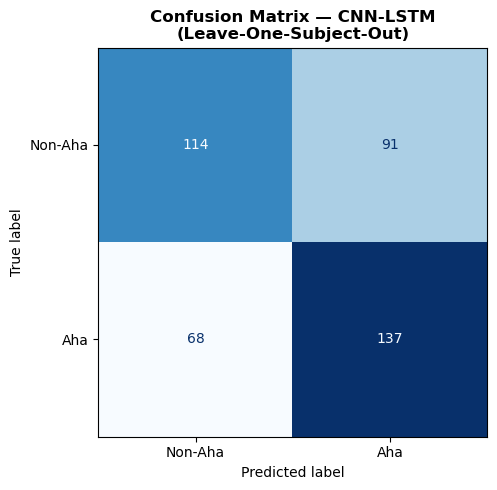


Best model: CNN-LSTM
              precision    recall  f1-score   support

     Non-Aha       0.63      0.56      0.59       205
         Aha       0.60      0.67      0.63       205

    accuracy                           0.61       410
   macro avg       0.61      0.61      0.61       410
weighted avg       0.61      0.61      0.61       410



In [10]:
print('=' * 55)
print('AHA MOMENT DETECTOR — RESULTS')
print('=' * 55)
print(f'\nTotal epochs: {len(X)} ({np.sum(y==1)} aha, {np.sum(y==0)} non-aha)')
print(f'Subjects: {len(np.unique(groups))}')
print(f'Chance level: 0.500\n')

print(f'{"Model":<12} {"Accuracy":>16} {"AUC":>16} {"F1":>10}')
print('-' * 55)
for name, res in [('EEGNet', eegnet_results), ('CNN-LSTM', cnnlstm_results)]:
    acc, auc, f1 = res[0], res[1], res[2]
    print(f'{name:<12} {np.mean(acc):>10.3f}±{np.std(acc):.3f} '
          f'{np.mean(auc):>10.3f}±{np.std(auc):.3f} {np.mean(f1):>10.3f}')

# Confusion matrix for best model (by AUC)
best_name, best_res = max(
    [('EEGNet', eegnet_results), ('CNN-LSTM', cnnlstm_results)],
    key=lambda x: np.mean(x[1][1])
)
preds, labels = best_res[3], best_res[4]

fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(labels, preds)
ConfusionMatrixDisplay(cm, display_labels=['Non-Aha', 'Aha']).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Confusion Matrix — {best_name}\n(Leave-One-Subject-Out)', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f'\nBest model: {best_name}')
print(classification_report(labels, preds, target_names=['Non-Aha', 'Aha']))